# DeepHalo Feature-Based Model - Example Usage

This notebook demonstrates how to use the **DeepHaloFeature** custom model that has been added to the choice-learn library.

The DeepHalo Feature-Based model is a ResNet-like deep neural network for discrete choice modeling that uses item features to learn complex choice patterns, including halo effects (item-item interactions). Unlike the featureless version, this model processes actual feature vectors for each item.

## Overview
- Load choice-learn's built-in dataset (ModeCanada)
- Prepare training and testing data (stratified split)
- Train DeepHaloFeature model
- Evaluate and visualize results
- Compare with SimpleMNL baseline

## Notes

**Data Imbalance Warning**: The ModeCanada dataset is highly imbalanced - certain transportation modes (Train, Car, Air) have very few or zero samples. You may see warnings like:
```
WARNING: Some choices never happen in the dataset: {0, 1, 3}
```
This indicates that these choice options don't appear in the dataset subset being used. This is a limitation of the dataset itself, not a code issue.

**Model Saving Warning**: When saving the model, you may see warnings about non-serializable attributes:
```
WARNING: Attribute 'aggregate_linears' is a list with non-serializable types...
```
These warnings are expected and can be safely ignored - all model weights are correctly saved and restored.

## 1. Import Required Libraries

In [1]:
import sys
sys.path.append("../../")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from choice_learn.data import ChoiceDataset
from choice_learn.datasets import load_modecanada
from choice_learn.models import DeepHaloFeature, SimpleMNL

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

2026-02-23 08:02:34.520467: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 08:02:34.590830: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 08:02:36.231363: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
NumPy version: 2.2.6
Pandas version: 2.3.3


## 2. Load ModeCanada Dataset

The ModeCanada dataset contains travel mode choices with various features:
- **Items**: 4 transportation modes (train, car, bus, air)
- **Features per mode**: cost, frequency, travel time, etc.
- **Shared features**: income, number of people in household, etc.

In [2]:
# Load the dataset
canada_dataset = load_modecanada(as_frame=False)

print(f"Dataset type: {type(canada_dataset)}")
print(f"Number of choices: {len(canada_dataset)}")
print(f"Number of items (modes): {canada_dataset.get_n_items()}")
print(f"Number of item features: {canada_dataset.get_n_items_features()}")
print(f"Number of shared features: {canada_dataset.get_n_shared_features()}")

Dataset type: <class 'choice_learn.data.choice_dataset.ChoiceDataset'>
Number of choices: 4324
Number of items (modes): 4
Number of item features: 4
Number of shared features: 3


## 3. Explore the Data

Let's examine a few samples and the overall class distribution to understand the data structure.

In [3]:
# Get a sample from the dataset
sample = canada_dataset[0]

print("Sample data structure:")
print(f"  Items features shape: {sample.items_features_by_choice[0].shape}")
print(f"  Shared features shape: {sample.shared_features_by_choice[0].shape if sample.shared_features_by_choice else 'None'}")
print(f"  Availability shape: {sample.available_items_by_choice.shape}")
print(f"  Choice: {sample.choices}")

# Show first sample details
print(f"\nFirst sample:")
print(f"  Item features (first mode):\n{sample.items_features_by_choice[0][0]}")
print(f"  Availability: {sample.available_items_by_choice}")
print(f"  Chosen mode: {sample.choices}")

# Check overall class distribution in the full dataset
print(f"\n{'='*50}")
print("FULL DATASET CLASS DISTRIBUTION:")
print('='*50)
all_choices_full = np.array([canada_dataset[i].choices for i in range(len(canada_dataset))]).flatten()
mode_names = ['Train (0)', 'Car (1)', 'Bus (2)', 'Air (3)']
for i in range(4):
    count = (all_choices_full == i).sum()
    percentage = count/len(canada_dataset)*100
    print(f"  {mode_names[i]}: {count} samples ({percentage:.1f}%)")
print(f"\nTotal samples: {len(canada_dataset)}")

Sample data structure:
  Items features shape: (1, 4, 4)
  Shared features shape: (1, 3)
  Availability shape: (1, 4)
  Choice: [2]

First sample:
  Item features (first mode):
[[0.0 0.0 0.0 0.0]
 [0.0 0.0 0.0 0.0]
 [15.77 0.0 0.0 61.0]
 [28.25 4.0 66.0 50.0]]
  Availability: [[0. 0. 1. 1.]]
  Chosen mode: [2]

FULL DATASET CLASS DISTRIBUTION:


  Train (0): 1472 samples (34.0%)
  Car (1): 16 samples (0.4%)
  Bus (2): 2213 samples (51.2%)
  Air (3): 623 samples (14.4%)

Total samples: 4324


## 4. Split Data into Train and Test Sets

In [4]:
# Use stratified split to ensure all classes are represented in both sets
from sklearn.model_selection import train_test_split

# Get all choices for stratification
all_choices = np.array([canada_dataset[i].choices for i in range(len(canada_dataset))]).flatten()

# Create indices
indices = np.arange(len(canada_dataset))

# Stratified split (80% train, 20% test)
train_indices, test_indices = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=all_choices,
    random_state=42
)

# Create train and test datasets using indices
train_dataset = canada_dataset[train_indices.tolist()]
test_dataset = canada_dataset[test_indices.tolist()]

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Verify class distribution
train_choices = np.array([train_dataset[i].choices for i in range(len(train_dataset))]).flatten()
test_choices = np.array([test_dataset[i].choices for i in range(len(test_dataset))]).flatten()

print(f"\nClass distribution in training set:")
for i in range(4):
    count = (train_choices == i).sum()
    print(f"  Class {i}: {count} ({count/len(train_dataset)*100:.1f}%)")

print(f"\nClass distribution in test set:")
for i in range(4):
    count = (test_choices == i).sum()
    print(f"  Class {i}: {count} ({count/len(test_dataset)*100:.1f}%)")

Training samples: 3459
Test samples: 865



Class distribution in training set:
  Class 0: 1178 (34.1%)
  Class 1: 13 (0.4%)
  Class 2: 1770 (51.2%)
  Class 3: 498 (14.4%)

Class distribution in test set:
  Class 0: 294 (34.0%)
  Class 1: 3 (0.3%)
  Class 2: 443 (51.2%)
  Class 3: 125 (14.5%)


## 5. Initialize DeepHaloFeature Model

Configure the model architecture:
- **H**: Number of heads in nonlinear transformation (4)
- **L**: Number of residual layers (3)
- **embed_dim**: Embedding dimension (64)
- **dropout**: Dropout rate for regularization (0.1)

In [5]:
# Model will infer n_items and input_dim from the dataset
model = DeepHaloFeature(
    H=4,
    L=3,
    embed_dim=64,
    dropout=0.1,
    optimizer='Adam',
    lr=0.001,
    epochs=50,
    batch_size=128
)

print("Model initialized successfully!")
print(f"Model will be instantiated during fit() with data dimensions")

I0000 00:00:1771833777.867969 1177543 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:18:00.0, compute capability: 7.0
I0000 00:00:1771833777.868588 1177543 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 31134 MB memory:  -> device: 1, name: Tesla V100-SXM2-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1771833777.869076 1177543 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 31134 MB memory:  -> device: 2, name: Tesla V100-SXM2-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0
I0000 00:00:1771833777.869487 1177543 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 31134 MB memory:  -> device: 3, name: Tesla V100-SXM2-32GB, pci bus id: 0000:af:00.0, compute capability: 7.0


Model initialized successfully!
Model will be instantiated during fit() with data dimensions


## 6. Train the Model

In [6]:
print("Training the model...")
history = model.fit(train_dataset, val_dataset=test_dataset, verbose=1)

print("\nTraining completed!")
print(f"Model dimensions:")
print(f"  - n_items: {model.n_items}")
print(f"  - input_dim: {model.input_dim}")
print(f"  - H: {model.H}")
print(f"  - L: {model.L}")
print(f"  - embed_dim: {model.embed_dim}")
print(f"\nFinal training loss: {history['train_loss'][-1]:.4f}")
print(f"Final validation loss: {history['val_loss'][-1]:.4f}")

Training the model...
DeepHaloFeature instantiated with n_items=4, input_dim=4 inferred from data.


Epoch 49 Train Loss 0.5828: 100%|██████████| 50/50 [00:56<00:00,  1.14s/it]



Training completed!
Model dimensions:
  - n_items: 4
  - input_dim: 4
  - H: 4
  - L: 3
  - embed_dim: 64

Final training loss: 0.5828
Final validation loss: 0.6604


## 7. Visualize Training Progress

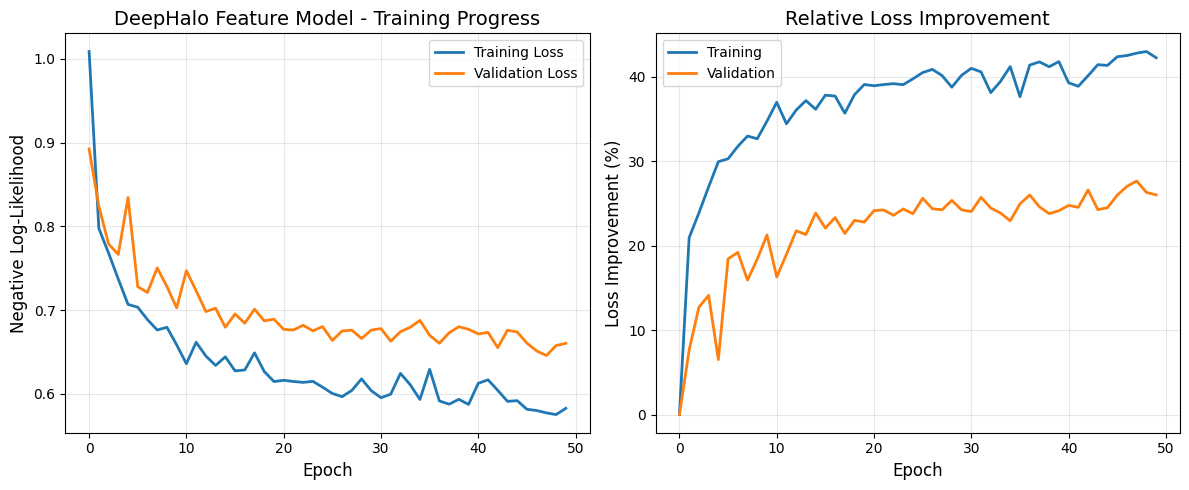

In [7]:
plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Negative Log-Likelihood', fontsize=12)
plt.title('DeepHalo Feature Model - Training Progress', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot loss improvement
plt.subplot(1, 2, 2)
train_improvement = (history['train_loss'][0] - np.array(history['train_loss'])) / history['train_loss'][0] * 100
val_improvement = (history['val_loss'][0] - np.array(history['val_loss'])) / history['val_loss'][0] * 100
plt.plot(train_improvement, label='Training', linewidth=2)
plt.plot(val_improvement, label='Validation', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Improvement (%)', fontsize=12)
plt.title('Relative Loss Improvement', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

In [8]:
# Calculate test metrics
test_nll = model.evaluate(test_dataset)
print(f"Test Negative Log-Likelihood: {test_nll:.4f}")

# Calculate accuracy
predictions = model.predict_probas(test_dataset)
predicted_choices = np.argmax(predictions, axis=1)

# Get actual choices from test dataset - flatten to ensure scalar values
actual_choices = np.array([test_dataset[i].choices for i in range(len(test_dataset))]).flatten()

accuracy = (predicted_choices == actual_choices).mean()
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Negative Log-Likelihood: 0.6599


Test Accuracy: 0.7665 (76.65%)


## 9. Analyze Predictions

Let's look at the prediction probabilities for a few samples.

In [9]:
# Show predictions for first 5 test samples
n_samples_show = 5
mode_names = ['Train', 'Car', 'Bus', 'Air']

print("Sample Predictions:\n")
for i in range(n_samples_show):
    print(f"Sample {i+1}:")
    print(f"  Actual choice: {mode_names[actual_choices[i]]}")
    print(f"  Predicted choice: {mode_names[predicted_choices[i]]}")
    print(f"  Probabilities:")
    for j, mode in enumerate(mode_names):
        print(f"    {mode}: {predictions[i, j]:.4f}")
    print()

Sample Predictions:

Sample 1:
  Actual choice: Bus
  Predicted choice: Air
  Probabilities:
    Train: 0.0399
    Car: 0.0008
    Bus: 0.1651
    Air: 0.7942

Sample 2:
  Actual choice: Bus
  Predicted choice: Bus
  Probabilities:
    Train: 0.0744
    Car: 0.0000
    Bus: 0.8998
    Air: 0.0258

Sample 3:
  Actual choice: Train
  Predicted choice: Train
  Probabilities:
    Train: 0.8072
    Car: 0.0012
    Bus: 0.1046
    Air: 0.0870

Sample 4:
  Actual choice: Bus
  Predicted choice: Bus
  Probabilities:
    Train: 0.1357
    Car: 0.0095
    Bus: 0.6083
    Air: 0.2465

Sample 5:
  Actual choice: Bus
  Predicted choice: Bus
  Probabilities:
    Train: 0.0501
    Car: 0.0383
    Bus: 0.8178
    Air: 0.0937



## 10. Visualize Prediction Distribution

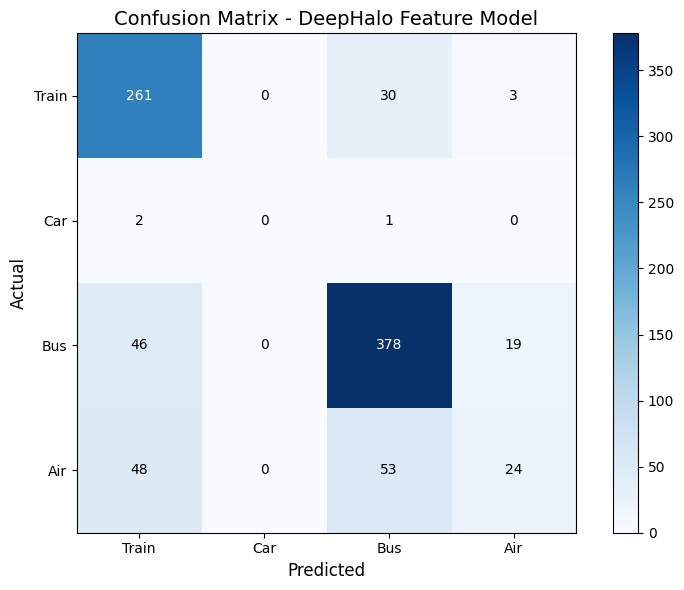


Per-class accuracy:
  Train: 0.8878 (88.78%)
  Car: 0.0000 (0.00%)
  Bus: 0.8533 (85.33%)
  Air: 0.1920 (19.20%)


In [10]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(actual_choices, predicted_choices)

plt.figure(figsize=(8, 6))

# Use matplotlib for heatmap (seaborn may not be installed)
import matplotlib.pyplot as plt
from matplotlib import colors

im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

# Add annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - DeepHalo Feature Model', fontsize=14)
plt.xticks(range(len(mode_names)), mode_names)
plt.yticks(range(len(mode_names)), mode_names)
plt.tight_layout()
plt.show()

# Print per-class accuracy
print("\nPer-class accuracy:")
for i, mode in enumerate(mode_names):
    class_accuracy = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f"  {mode}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

## 11. Compare with Baseline Model (SimpleMNL)

Let's compare DeepHaloFeature with a simple Multinomial Logit model.

In [11]:
# Train SimpleMNL for comparison
print("Training SimpleMNL baseline...")
mnl_model = SimpleMNL(optimizer="Adam", lr=0.01, epochs=50, batch_size=128)
mnl_history = mnl_model.fit(train_dataset, val_dataset=test_dataset, verbose=0)

# Evaluate
mnl_test_nll = mnl_model.evaluate(test_dataset)
mnl_predictions = mnl_model.predict_probas(test_dataset)
mnl_predicted_choices = np.argmax(mnl_predictions, axis=1)
mnl_accuracy = (mnl_predicted_choices == actual_choices).mean()

print(f"\nSimpleMNL Results:")
print(f"  Test NLL: {mnl_test_nll:.4f}")
print(f"  Test Accuracy: {mnl_accuracy:.4f} ({mnl_accuracy*100:.2f}%)")

print(f"\nDeepHaloFeature Results:")
print(f"  Test NLL: {test_nll:.4f}")
print(f"  Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\nImprovement:")
nll_improvement = (mnl_test_nll - test_nll) / mnl_test_nll * 100
acc_improvement = (accuracy - mnl_accuracy) / mnl_accuracy * 100
print(f"  NLL: {nll_improvement:.2f}% better")
print(f"  Accuracy: {acc_improvement:.2f}% better")

Training SimpleMNL baseline...


Epoch 49 Train Loss 0.7944: 100%|██████████| 50/50 [00:05<00:00,  9.27it/s]



SimpleMNL Results:
  Test NLL: 0.9693
  Test Accuracy: 0.7133 (71.33%)

DeepHaloFeature Results:
  Test NLL: 0.6599
  Test Accuracy: 0.7665 (76.65%)

Improvement:
  NLL: 31.92% better
  Accuracy: 7.46% better


## 12. Visualize Model Comparison

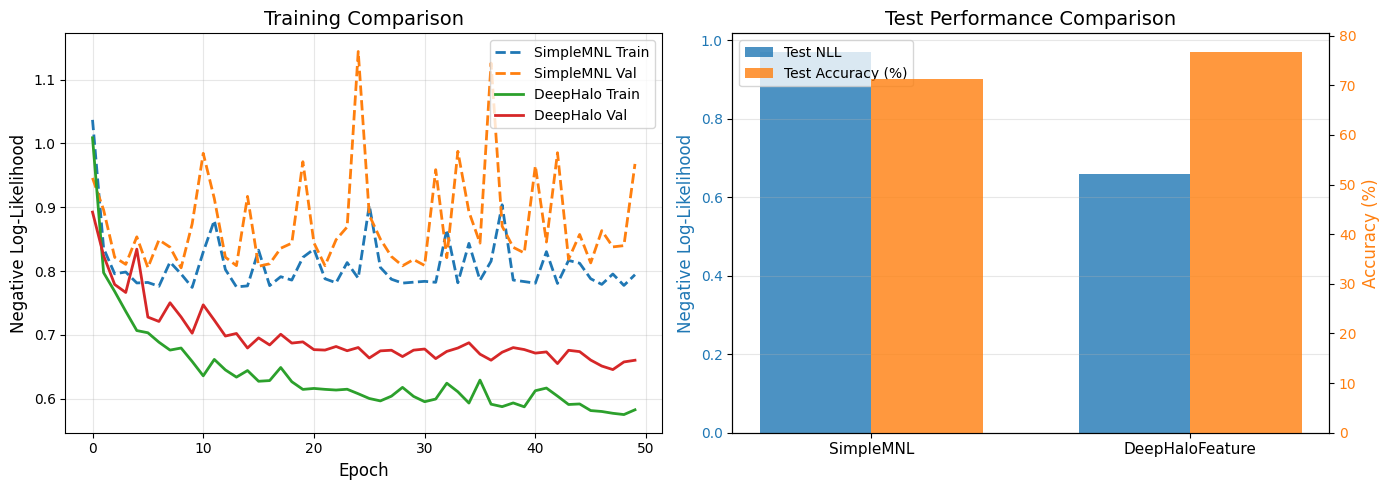

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training curves
axes[0].plot(mnl_history['train_loss'], label='SimpleMNL Train', linestyle='--', linewidth=2)
axes[0].plot(mnl_history['val_loss'], label='SimpleMNL Val', linestyle='--', linewidth=2)
axes[0].plot(history['train_loss'], label='DeepHalo Train', linewidth=2)
axes[0].plot(history['val_loss'], label='DeepHalo Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Negative Log-Likelihood', fontsize=12)
axes[0].set_title('Training Comparison', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Performance comparison
models = ['SimpleMNL', 'DeepHaloFeature']
nlls = [mnl_test_nll, test_nll]
accs = [mnl_accuracy * 100, accuracy * 100]

x = np.arange(len(models))
width = 0.35

bars1 = axes[1].bar(x - width/2, nlls, width, label='Test NLL', alpha=0.8)
axes[1].set_ylabel('Negative Log-Likelihood', fontsize=12, color='C0')
axes[1].tick_params(axis='y', labelcolor='C0')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=11)

ax2 = axes[1].twinx()
bars2 = ax2.bar(x + width/2, accs, width, label='Test Accuracy (%)', alpha=0.8, color='C1')
ax2.set_ylabel('Accuracy (%)', fontsize=12, color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

axes[1].set_title('Test Performance Comparison', fontsize=14)
axes[1].legend(handles=[bars1, bars2], loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 13. Feature Importance Analysis

Let's examine which features the model finds most important by looking at the learned embeddings.

Feature importance (based on encoder weights):
  Feature 0: 0.2349
  Feature 1: 0.3420
  Feature 2: 0.2270
  Feature 3: 0.1962


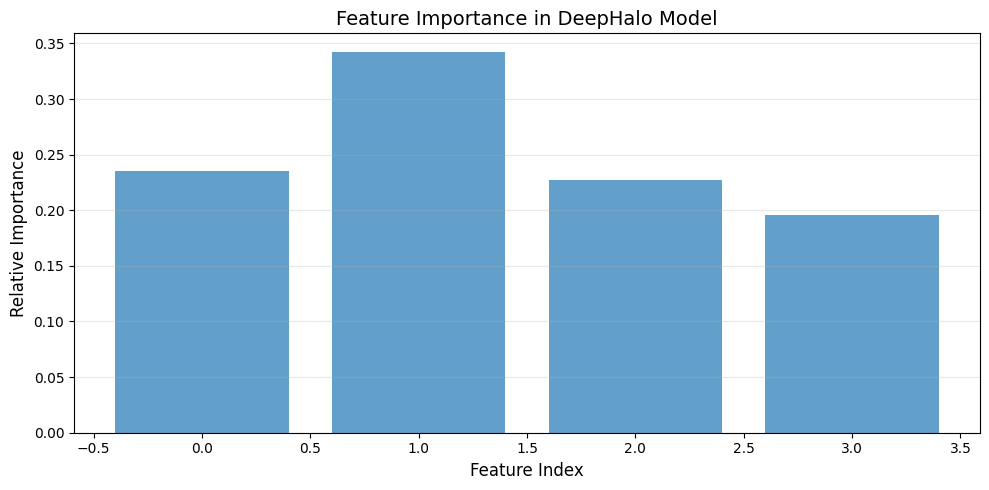

In [13]:
# Get the first layer weights (basic encoder)
encoder_weights = model.basic_encoder.layers[0].get_weights()[0]  # Shape: (input_dim, embed_dim)

# Calculate average magnitude per input feature
feature_importance = np.abs(encoder_weights).mean(axis=1)

# Normalize
feature_importance = feature_importance / feature_importance.sum()

print("Feature importance (based on encoder weights):")
for i, importance in enumerate(feature_importance):
    print(f"  Feature {i}: {importance:.4f}")

# Visualize
plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_importance)), feature_importance, alpha=0.7)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Relative Importance', fontsize=12)
plt.title('Feature Importance in DeepHalo Model', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 14. Save and Load the Model

In [14]:
import os
import shutil

# Save model
save_path = "saved_models/deephalo_feature_canada"
os.makedirs(save_path, exist_ok=True)

print(f"Saving model to {save_path}...")
model.save_model(save_path)
print("Model saved successfully!")

# Load model
print(f"\nLoading model from {save_path}...")
loaded_model = DeepHaloFeature.load_model(save_path)
print("Model loaded successfully!")

# Verify loaded model
loaded_predictions = loaded_model.predict_probas(test_dataset)
prediction_diff = np.abs(predictions - loaded_predictions).max()
print(f"\nPrediction difference due to dropout: {prediction_diff:.10f}")

# Clean up (optional)
# shutil.rmtree(save_path)
# print(f"Cleaned up saved model directory")

                         types and will not be saved.
                         types and will not be saved.


Saving model to saved_models/deephalo_feature_canada...
Model saved successfully!

Loading model from saved_models/deephalo_feature_canada...
Model loaded successfully!

Prediction difference due to dropout: 0.5048235059
